In [5]:
# Model from scikit-learn
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Model Evaluations
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve
from sklearn.model_selection import TunedThresholdClassifierCV, TimeSeriesSplit, RandomizedSearchCV

In [6]:
import numpy as np

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style='darkgrid')
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
raw_data = pd.read_csv('../data/processed/mhd_ch4_simple_v1.csv')
raw_data.head()
data = raw_data.copy()
data = data.drop(data[data['year']==2026].index)
print(data['year'].unique())
print(data.columns)

[1994 1995 1996 1997 1998 1999 2000 2001 2002 2003 2004 2005 2006 2007
 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021
 2022 2023 2024 2025]
Index(['date', 'time', 'type', 'sample', 'standard', 'port', 'ht', 'tmod',
       'tamb', 'lab_temp', 'pflow', 'psamp', 'ploop', 'pamb', 'CH4_rt',
       'CH4_w', 'CH4_ht', 'CH4_area', 'CH4_skew', 'CH4_start_time',
       'CH4_end_time', 'CH4_start_level', 'CH4_end_level', 'CH4_flag_ht',
       'CH4_flag_a', 'CH4_flag', 'CH4_flag_p', 'label1', 'datetime_str',
       'datetime', 'is_ht_999', 'is_area_999', 'is_rt_zero', 'is_w_zero',
       'duration', 'ht_area_ratio', 'type_std', 'type_air', 'type_tank',
       'type_blank', 'type_cal', 'type_other', 'year', 'month', 'day', 'hour',
       'minute', 'seconds'],
      dtype='object')


In [8]:
year_dummies = pd.get_dummies(data['year'], prefix='is_year_').astype(int)
data = pd.concat([data, year_dummies], axis=1)
data.head()

,date,time,type,sample,standard,port,ht,tmod,tamb,lab_temp,pflow,psamp,ploop,pamb,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p,label1,datetime_str,datetime,is_ht_999,is_area_999,is_rt_zero,is_w_zero,duration,ht_area_ratio,type_std,type_air,type_tank,type_blank,type_cal,type_other,year,month,day,hour,minute,seconds,is_year__1994,is_year__1995,is_year__1996,is_year__1997,is_year__1998,is_year__1999,is_year__2000,is_year__2001,is_year__2002,is_year__2003,is_year__2004,is_year__2005,is_year__2006,is_year__2007,is_year__2008,is_year__2009,is_year__2010,is_year__2011,is_year__2012,is_year__2013,is_year__2014,is_year__2015,is_year__2016,is_year__2017,is_year__2018,is_year__2019,is_year__2020,is_year__2021,is_year__2022,is_year__2023,is_year__2024,is_year__2025
0,940216,142900,air,10m,G-024,3,10.0,40.00,32.27,NaN,841.9,761.10,NaN,761.1,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,F,F,,,1,940216142900,1994-02-16 14:29:00,False,False,True,True,0.0,NaN,0,1,0,0,0,0,1994,2,16,14,29,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,940216,144900,air,10m,G-024,3,10.0,40.00,32.48,NaN,840.4,761.07,NaN,761.2,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,F,F,,,1,940216144900,1994-02-16 14:49:00,False,False,True,True,0.0,NaN,0,1,0,0,0,0,1994,2,16,14,49,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,940216,150900,air,10m,G-024,3,10.0,40.01,32.75,NaN,839.4,760.99,NaN,760.9,109.8,2.60,190908.0,496440.0,0.63,102.0,135.4,10063.0,10029.0,F,F,,,1,940216150900,1994-02-16 15:09:00,False,False,False,False,33.4,0.384554,0,1,0,0,0,0,1994,2,16,15,9,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,940216,152900,air,10m,G-024,3,10.0,40.00,32.92,NaN,839.6,760.96,NaN,760.9,94.8,6.85,151667.0,1065982.0,1.02,86.2,129.0,99999.0,99999.0,,,,,0,940216152900,1994-02-16 15:29:00,False,False,False,False,42.8,0.142279,0,1,0,0,0,0,1994,2,16,15,29,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,940216,180000,air,10m,G-024,3,10.0,40.00,33.31,NaN,845.4,760.72,NaN,760.6,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,F,F,,,1,940216180000,1994-02-16 18:00:00,False,False,True,True,0.0,NaN,0,1,0,0,0,0,1994,2,16,18,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [9]:
data = data.set_index('datetime')
data = data.reset_index()

In [10]:
def fill_Nan(df, feature_col):
    df = df.copy()
    for i in feature_col:
        df[i] = df[i].ffill()
    return df


In [11]:
feature_cols = [
    #'sample'	,'standard',	
    #'port'	,'ht',
    'tmod'	,'tamb',
    'pflow', 'psamp',
    'pamb'	,
    'CH4_rt',	'CH4_w',	'CH4_ht'	,
    'CH4_area',	'CH4_skew'	,
    'CH4_start_time',	'CH4_end_time'	,'CH4_start_level',	'CH4_end_level',
    'duration', 
]

In [12]:
fill_df= data.copy()
fill_df = fill_Nan(fill_df, feature_cols)

In [13]:
fill_df.isna().sum()

datetime                0
date                    0
time                    0
type                    0
sample                  0
standard                0
port                    0
ht                      0
tmod                    0
tamb                    0
lab_temp           808210
pflow                   0
psamp                   0
ploop              808210
pamb                    0
CH4_rt                  0
CH4_w                   0
CH4_ht                  0
CH4_area                0
CH4_skew                0
CH4_start_time          0
CH4_end_time            0
CH4_start_level         0
CH4_end_level           0
CH4_flag_ht             0
CH4_flag_a              0
CH4_flag                0
CH4_flag_p              0
label1                  0
datetime_str            0
is_ht_999               0
is_area_999             0
is_rt_zero              0
is_w_zero               0
duration                0
ht_area_ratio       18277
type_std                0
type_air                0
type_tank   

In [14]:
fill_df.columns

Index(['datetime', 'date', 'time', 'type', 'sample', 'standard', 'port', 'ht',
       'tmod', 'tamb', 'lab_temp', 'pflow', 'psamp', 'ploop', 'pamb', 'CH4_rt',
       'CH4_w', 'CH4_ht', 'CH4_area', 'CH4_skew', 'CH4_start_time',
       'CH4_end_time', 'CH4_start_level', 'CH4_end_level', 'CH4_flag_ht',
       'CH4_flag_a', 'CH4_flag', 'CH4_flag_p', 'label1', 'datetime_str',
       'is_ht_999', 'is_area_999', 'is_rt_zero', 'is_w_zero', 'duration',
       'ht_area_ratio', 'type_std', 'type_air', 'type_tank', 'type_blank',
       'type_cal', 'type_other', 'year', 'month', 'day', 'hour', 'minute',
       'seconds', 'is_year__1994', 'is_year__1995', 'is_year__1996',
       'is_year__1997', 'is_year__1998', 'is_year__1999', 'is_year__2000',
       'is_year__2001', 'is_year__2002', 'is_year__2003', 'is_year__2004',
       'is_year__2005', 'is_year__2006', 'is_year__2007', 'is_year__2008',
       'is_year__2009', 'is_year__2010', 'is_year__2011', 'is_year__2012',
       'is_year__2013', 'is_year_

In [15]:
fill_df['label1'].value_counts()

label1
0    769380
1     38831
Name: count, dtype: int64

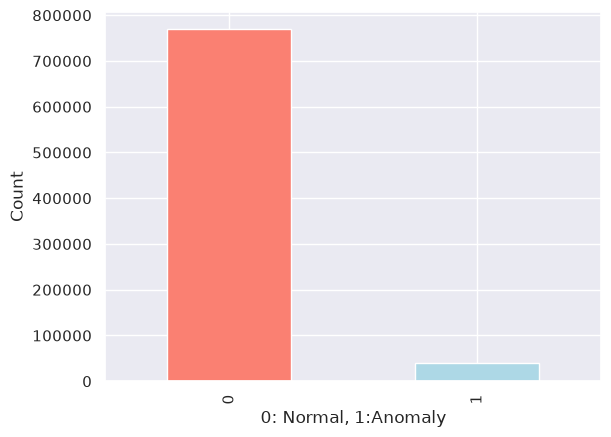

In [16]:
fill_df['label1'].value_counts().plot.bar(color=['salmon', 'lightblue'])
plt.xlabel('0: Normal, 1:Anomaly')
plt.ylabel('Count')
plt.show()

In [17]:
needed_col = [#'datetime', 'date', 'time', 'type', 'sample', 'standard', 
        'port', 'ht',
       'tmod', 'tamb', 'pflow', 'psamp', 'pamb', 'CH4_rt',
       'CH4_w', 'CH4_ht', 'CH4_area', 'CH4_skew', 'CH4_start_time',
       'CH4_end_time', 'CH4_start_level', 'CH4_end_level', 
       #'CH4_flag_ht','CH4_flag_a', 'CH4_flag', 'CH4_flag_p', 
       'label1']

In [18]:
fill_df[needed_col].describe().transpose()

,count,mean,std,min,25%,50%,75%,max
port,808211.0,2.965196e+00,7.474986e+00,0.00,1.00,3.00,3.00,119.0
ht,808211.0,4.494983e+00,4.933942e+00,0.00,0.00,0.00,10.00,40.0
tmod,808211.0,4.180885e+01,1.736148e+01,-22.00,40.00,40.00,40.00,186.0
tamb,808211.0,2.734186e+01,4.094565e+01,10.57,19.91,20.58,21.58,1225.0
pflow,808211.0,8.144921e+02,1.571971e+03,159.90,801.10,809.70,819.00,999999.0
psamp,808211.0,7.578451e+02,6.635292e+01,182.71,750.62,757.64,763.59,12922.0
pamb,808211.0,7.566576e+02,9.874317e+00,94.60,750.70,757.60,763.50,1505.9
CH4_rt,808211.0,9.655575e+01,1.442399e+01,0.00,96.40,98.60,100.60,166.6
CH4_w,808211.0,7.952133e+00,8.055249e+01,0.00,7.69,7.87,8.39,72415.0
CH4_ht,808211.0,1.537866e+05,2.346313e+05,0.00,142866.00,151918.00,168352.00,99999999.0


In [19]:
corr = data[needed_col].corr()

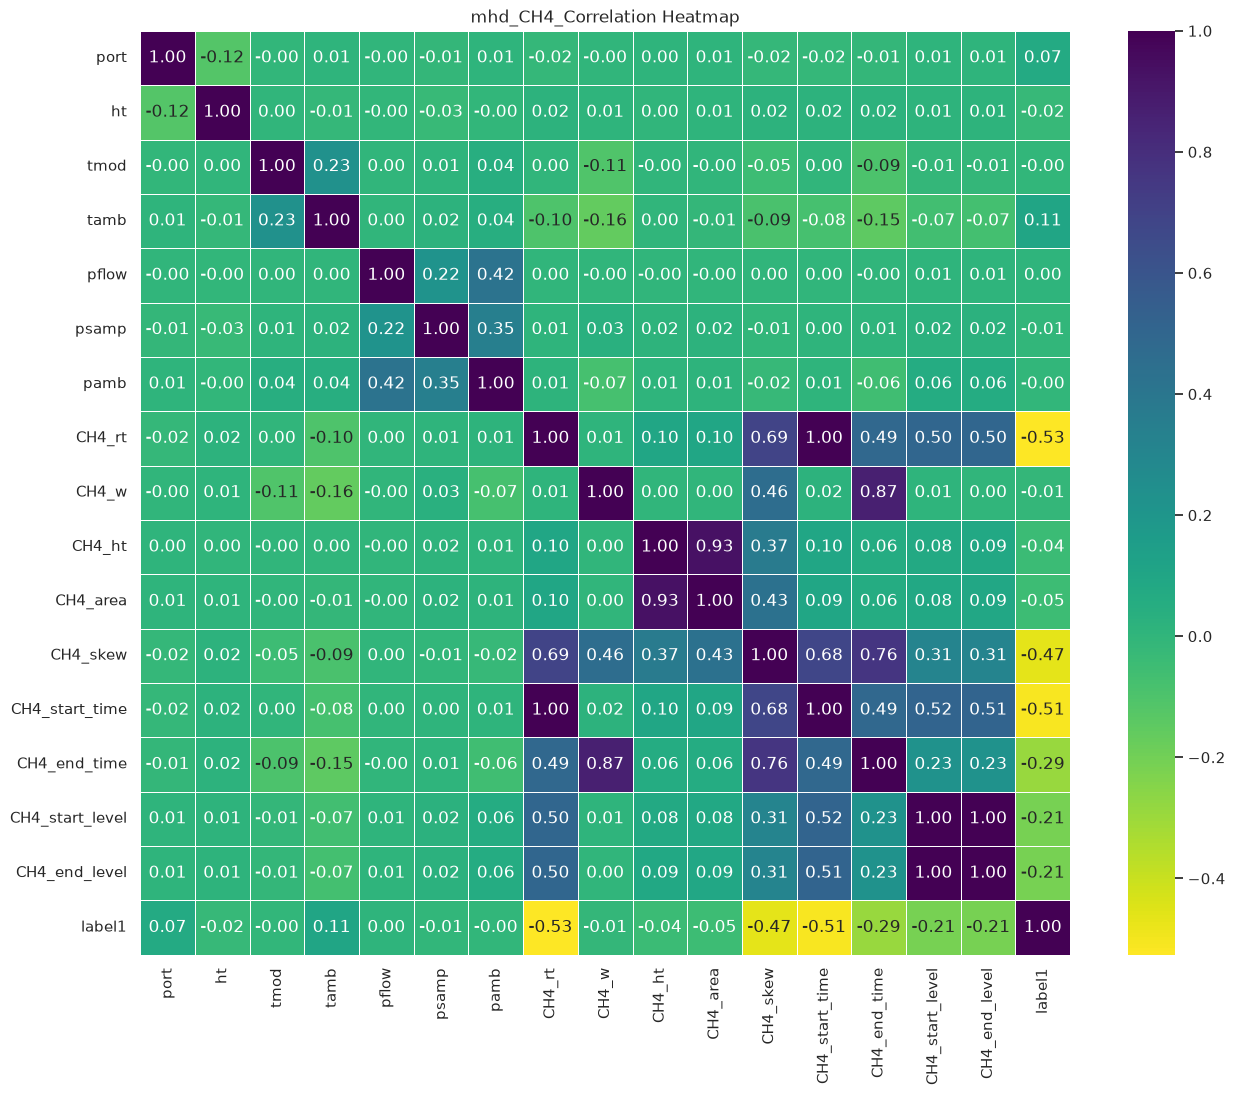

In [17]:
plt.figure(figsize=(15, 12))

sns.heatmap(corr,
            annot=True,
            cmap='viridis_r',
            fmt='.2f',
            linewidths=0.5)

plt.title('mhd_CH4_Correlation Heatmap')
plt.show()

label1: normal data represents as 0, anomaly represents as 1
-------------------------
summary: the lower the value of CH4_rt and CH4_start_time, it is more possible the data will be classified as  (abnormal).


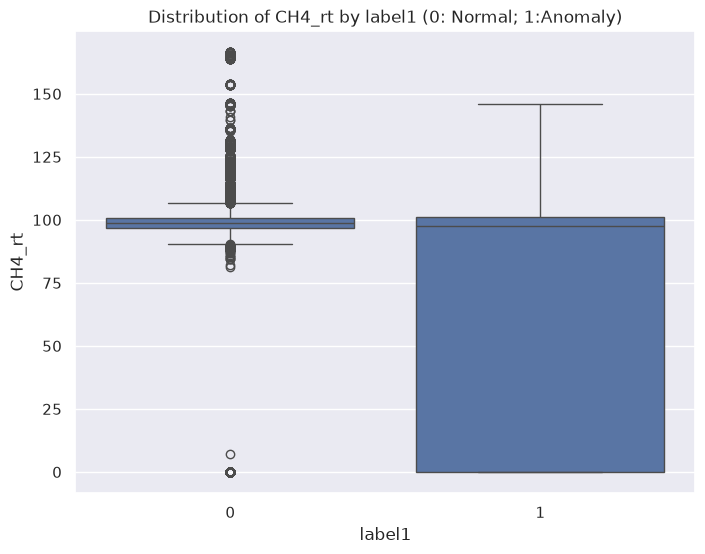

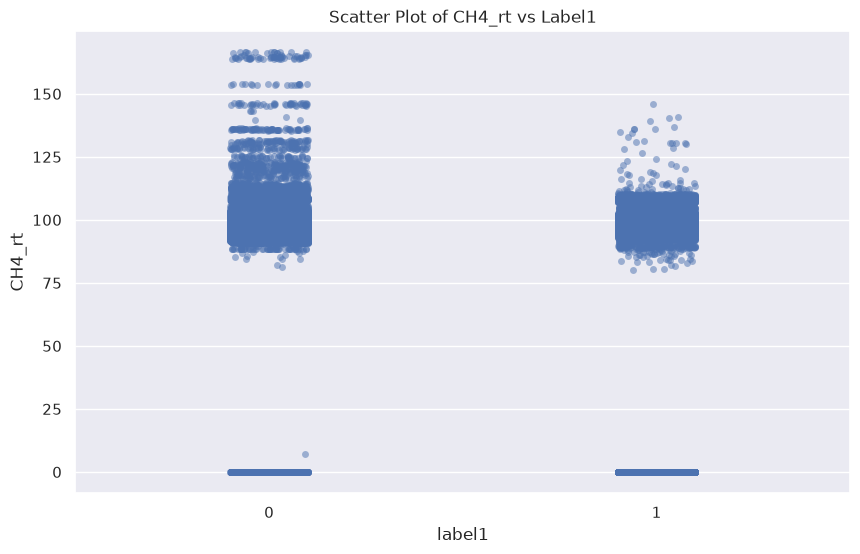

In [18]:
# CH4_rt boxplot
plt.figure(figsize=(8,6))
sns.boxplot(x='label1', y='CH4_rt', data=fill_df)
plt.title('Distribution of CH4_rt by label1 (0: Normal; 1:Anomaly)')
plt.show()

plt.figure(figsize=(10, 6))

sns.stripplot(x='label1', y='CH4_rt', data=fill_df, jitter=True, alpha=0.5)
plt.title('Scatter Plot of CH4_rt vs Label1')
plt.show()

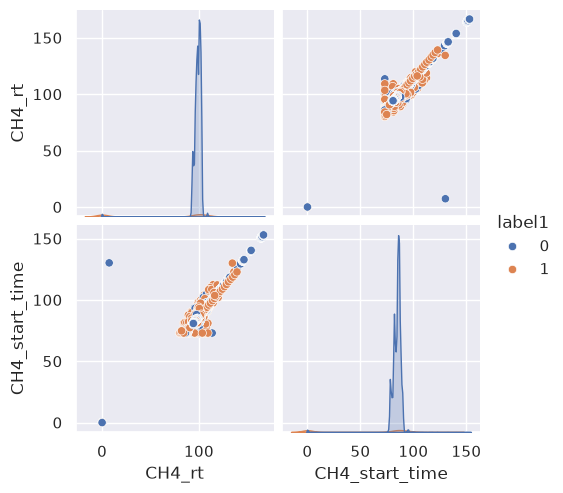

In [19]:
sns.pairplot(fill_df, hue='label1', vars=['CH4_rt', 'CH4_start_time'])
plt.show()

###### label1 : 0 -> normal; 1-> abnormal


# ML

In [20]:
ml_col = [#'datetime', 'date', 'time', 'type', 'sample', 'standard', 
        'port', 'ht',
       'tmod', 'tamb', 'pflow', 'psamp', 'pamb', 'CH4_rt',
       'CH4_w', 'CH4_ht', 'CH4_area', 'CH4_skew', 'CH4_start_time',
       'CH4_end_time', 'CH4_start_level', 'CH4_end_level', 
       #'CH4_flag_ht','CH4_flag_a', 'CH4_flag', 'CH4_flag_p', 
       ]

In [21]:
ml_df = data.copy()

ml_df.isna().sum()

datetime                0
date                    0
time                    0
type                    0
sample                  0
standard                0
port                    0
ht                      0
tmod               112284
tamb               112285
lab_temp           808210
pflow                2402
psamp                2330
ploop              808210
pamb                 2404
CH4_rt               1590
CH4_w                1590
CH4_ht               1590
CH4_area             1590
CH4_skew             1590
CH4_start_time       1590
CH4_end_time         1590
CH4_start_level      1590
CH4_end_level        1590
CH4_flag_ht             0
CH4_flag_a              0
CH4_flag                0
CH4_flag_p              0
label1                  0
datetime_str            0
is_ht_999               0
is_area_999             0
is_rt_zero              0
is_w_zero               0
duration             1590
ht_area_ratio       18277
type_std                0
type_air                0
type_tank   

In [22]:
# data split by time ( no random-)
X = ml_df[ml_col]
y = ml_df['label1']
feature_cols = X.columns.tolist()
split_idx = int(len(ml_df)*0.8)


X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Handle nan values, forwardfill
X_train_filled = fill_Nan(X_train, feature_cols)
X_test_filled = fill_Nan(X_test, feature_cols)


In [23]:
# scaler
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train_filled)
X_test_scaled = scaler.fit_transform(X_test_filled)

In [24]:
X_train_scaled.shape, X_test.shape, y_train.shape, y_test.shape

((646568, 16), (161643, 16), (646568,), (161643,))

## Model Training
 try 3 different models.
 1. Logistic Regression
 2. K-Nearest Neighbours Classifer
 3. Random Forest Classier

In [25]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN':KNeighborsClassifier(n_neighbors = 2),
    'RandomForestClassier':RandomForestClassifier(n_estimators=200,max_depth=12,random_state=42, n_jobs=-1)
}

def modelfit_and_score(models, X_train, X_test, y_train, y_test):
    """
    Fits and evaluate ML models.
    models: dictionary of different ML models
    X_train: training data (no labels)
    X_test: testinh data (no labels)
    y_train: training labels
    y_test: testing labels
    returns model scores dictionary
    """
    precision_val = 2.0
    np.random.seed(42)

    model_scores = {}

    for model_name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        # focuse on anomaly 
        precision_val = precision_score(y_test, y_pred, pos_label=1)

        model_scores[model_name] = precision_val
        print(f'---- { model_name} Report')
        print(classification_report(y_test, y_pred))

    return model_scores

In [92]:
model_scores= modelfit_and_score(models, X_train_scaled, X_test_filled, y_train, y_test)
print("ANomaly dettection precision:", model_scores)

/home/ellie/research_project/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


---- Logistic Regression Report
              precision    recall  f1-score   support

           0       0.90      1.00      0.94    144705
           1       0.89      0.00      0.00     16938

    accuracy                           0.90    161643
   macro avg       0.89      0.50      0.47    161643
weighted avg       0.89      0.90      0.85    161643



/home/ellie/research_project/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


---- KNN Report
              precision    recall  f1-score   support

           0       0.92      1.00      0.96    144705
           1       0.97      0.29      0.44     16938

    accuracy                           0.92    161643
   macro avg       0.94      0.64      0.70    161643
weighted avg       0.93      0.92      0.91    161643



/home/ellie/research_project/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


---- RandomForestClassier Report
              precision    recall  f1-score   support

           0       0.87      0.53      0.66    144705
           1       0.07      0.32      0.12     16938

    accuracy                           0.51    161643
   macro avg       0.47      0.42      0.39    161643
weighted avg       0.79      0.51      0.60    161643

ANomaly dettection precision: {'Logistic Regression': 0.8888888888888888, 'KNN': 0.9660377358490566, 'RandomForestClassier': 0.07313402481187715}


## Improve RF model


自我提醒: 先拆分再做特徵以及處理NAN值
rf moddel 不用縮放

### Feature eng


In [22]:
data.columns

Index(['datetime', 'date', 'time', 'type', 'sample', 'standard', 'port', 'ht',
       'tmod', 'tamb', 'lab_temp', 'pflow', 'psamp', 'ploop', 'pamb', 'CH4_rt',
       'CH4_w', 'CH4_ht', 'CH4_area', 'CH4_skew', 'CH4_start_time',
       'CH4_end_time', 'CH4_start_level', 'CH4_end_level', 'CH4_flag_ht',
       'CH4_flag_a', 'CH4_flag', 'CH4_flag_p', 'label1', 'datetime_str',
       'is_ht_999', 'is_area_999', 'is_rt_zero', 'is_w_zero', 'duration',
       'ht_area_ratio', 'type_std', 'type_air', 'type_tank', 'type_blank',
       'type_cal', 'type_other', 'year', 'month', 'day', 'hour', 'minute',
       'seconds', 'is_year__1994', 'is_year__1995', 'is_year__1996',
       'is_year__1997', 'is_year__1998', 'is_year__1999', 'is_year__2000',
       'is_year__2001', 'is_year__2002', 'is_year__2003', 'is_year__2004',
       'is_year__2005', 'is_year__2006', 'is_year__2007', 'is_year__2008',
       'is_year__2009', 'is_year__2010', 'is_year__2011', 'is_year__2012',
       'is_year__2013', 'is_year_

In [23]:
def ratio_featutre_gen(df):
    df = df.copy()
    df['CH4_area_ht_ratio'] = df['CH4_area']/df['CH4_ht']
    df['CH4_w_ht_ratio'] = df['CH4_w']/df['CH4_ht']
    df['psamp_pflow_ratio'] = df['psamp']/df['pflow']
    df['w_duration_ratio'] = df['CH4_w']/df['duration']

    fill_feature_ratio = ['CH4_area_ht_ratio', 'CH4_w_ht_ratio', 'psamp_pflow_ratio','w_duration_ratio']
    for i in fill_feature_ratio :
        df[i] = df[i].fillna(0)
        
    return df

#=============== diff, lag, rolling
def diff_gen(df, feature, period):
    df = df.copy()
    df[f'{feature}_diff_{period}'] = (df[f'{feature}'].diff(period)).fillna(0)

    return df
#===============
def lag_gen (df, feature, period):
    df = df.copy()
    df[f'{feature}_lag_{period}'] = (df[f'{feature}'].shift(period)).fillna(0)
    return df

#===============
def rolling_std_gen (df, feature, period):
    df = df.copy()
    df[f'{feature}_roll_std_{period}'] = (df[f'{feature}'].rolling(window=pd.to_timedelta(period), closed='left').std()).fillna(0)# self not included, NAN->0
    return df

#===============
def rolling_mean_residual_gen(df, feature, period):
    df = df.copy()
    df[f'{feature}_roll_mean_{period}'] = df[f'{feature}'].rolling(window=pd.to_timedelta(period), closed='left').mean().fillna(0) # self not included
    df[f'{feature}_residual_{period}'] = df[f'{feature}']- df[f'{feature}_roll_mean_{period}']# self not included
    return df

In [24]:
rf_df = data.copy()
rf_df.columns

Index(['datetime', 'date', 'time', 'type', 'sample', 'standard', 'port', 'ht',
       'tmod', 'tamb', 'lab_temp', 'pflow', 'psamp', 'ploop', 'pamb', 'CH4_rt',
       'CH4_w', 'CH4_ht', 'CH4_area', 'CH4_skew', 'CH4_start_time',
       'CH4_end_time', 'CH4_start_level', 'CH4_end_level', 'CH4_flag_ht',
       'CH4_flag_a', 'CH4_flag', 'CH4_flag_p', 'label1', 'datetime_str',
       'is_ht_999', 'is_area_999', 'is_rt_zero', 'is_w_zero', 'duration',
       'ht_area_ratio', 'type_std', 'type_air', 'type_tank', 'type_blank',
       'type_cal', 'type_other', 'year', 'month', 'day', 'hour', 'minute',
       'seconds', 'is_year__1994', 'is_year__1995', 'is_year__1996',
       'is_year__1997', 'is_year__1998', 'is_year__1999', 'is_year__2000',
       'is_year__2001', 'is_year__2002', 'is_year__2003', 'is_year__2004',
       'is_year__2005', 'is_year__2006', 'is_year__2007', 'is_year__2008',
       'is_year__2009', 'is_year__2010', 'is_year__2011', 'is_year__2012',
       'is_year__2013', 'is_year_

In [25]:
feature_cols = [
    'datetime',
    #'sample'	,'standard',	
    #'port'	,'ht',
    'tmod'	,'tamb',
    'pflow', 'psamp',
    'pamb'	,
    'CH4_rt',	'CH4_w',	'CH4_ht'	,
    'CH4_area',	'CH4_skew'	,
    'CH4_start_time',	'CH4_end_time'	,'CH4_start_level',	'CH4_end_level',
    'duration', 
]

In [26]:
X = rf_df[feature_cols]
y = rf_df['label1']
feature_cols = X.columns.tolist()
split_idx = int(len(ml_df)*0.8)


X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Handle nan values, forwardfill

In [27]:
X_train_final = X_train.copy()
X_test_final = X_test.copy()

X_train_final.head()

,datetime,tmod,tamb,pflow,psamp,pamb,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,duration
0,1994-02-16 14:29:00,40.00,32.27,841.9,761.10,761.1,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0
1,1994-02-16 14:49:00,40.00,32.48,840.4,761.07,761.2,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0
2,1994-02-16 15:09:00,40.01,32.75,839.4,760.99,760.9,109.8,2.60,190908.0,496440.0,0.63,102.0,135.4,10063.0,10029.0,33.4
3,1994-02-16 15:29:00,40.00,32.92,839.6,760.96,760.9,94.8,6.85,151667.0,1065982.0,1.02,86.2,129.0,99999.0,99999.0,42.8
4,1994-02-16 18:00:00,40.00,33.31,845.4,760.72,760.6,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0


In [28]:
eng_cols = [
    #'sample'	,'standard',	
    #'port'	,'ht',
    'tmod'	,'tamb',
    'pflow', 'psamp',
    'pamb'	,
    'CH4_rt',	'CH4_w',	'CH4_ht'	,
    'CH4_area',	'CH4_skew'	,
    'CH4_start_time',	'CH4_end_time'	,'CH4_start_level',	'CH4_end_level',
    'duration', 
]

In [29]:
X_train_final = X_train.copy()
X_test_final = X_test.copy()

# set date as index
X_train_final  =X_train_final.set_index('datetime')
X_test_final = X_test_final.set_index('datetime')

# fill NAN values
X_train_final = fill_Nan(X_train_final, eng_cols)
X_test_final= fill_Nan(X_test_final, eng_cols)

# create ratio feature
X_train_final  = ratio_featutre_gen(X_train_final)
X_test_final= ratio_featutre_gen(X_test_final)

# conver date index as pd datatime type
X_train_final.index = pd.to_datetime(X_train_final.index)
X_test_final.index = pd.to_datetime(X_test_final.index)

In [30]:
feature_config ={
    'diff':{'cols': ['CH4_area', 'CH4_ht', 'CH4_rt'], 'periods':1},
    'lag':{'cols':['CH4_area', 'CH4_rt', 'tmod', 'tamb','pflow', 'psamp','pamb'], 'periods':1 },
    'roll_std':{'cols': ['CH4_w', 'CH4_skew'], 'period':'14D'},
    'roll_mean_res':{'cols':['CH4_rt', 'CH4_start_time', 'CH4_w', 'CH4_skew'], 'period': '14D'}
}

def feature_eng_apply(df, config):
    df = df.copy()

    for opt, params in config.items():
        cols = params['cols']
        period = params.get('period') or params.get('periods', 1) # period's value -> periods's -> 1

        for feature in cols:
            if opt == 'diff':
                df = diff_gen(df, feature, period)
            elif opt == 'lag':
                df = lag_gen(df, feature, period)
            elif opt == 'roll_std':
                df = rolling_std_gen(df, feature, period)
            elif opt == 'roll_mean_res':
                df = rolling_mean_residual_gen(df, feature, period)
    return df 


In [31]:
X_train_final= feature_eng_apply(X_train_final, feature_config)
X_test_final= feature_eng_apply(X_test_final, feature_config)

In [32]:
X_train_final.isna().sum()

tmod                            0
tamb                            0
pflow                           0
psamp                           0
pamb                            0
CH4_rt                          0
CH4_w                           0
CH4_ht                          0
CH4_area                        0
CH4_skew                        0
CH4_start_time                  0
CH4_end_time                    0
CH4_start_level                 0
CH4_end_level                   0
duration                        0
CH4_area_ht_ratio               0
CH4_w_ht_ratio                  0
psamp_pflow_ratio               0
w_duration_ratio                0
CH4_area_diff_1                 0
CH4_ht_diff_1                   0
CH4_rt_diff_1                   0
CH4_area_lag_1                  0
CH4_rt_lag_1                    0
tmod_lag_1                      0
tamb_lag_1                      0
pflow_lag_1                     0
psamp_lag_1                     0
pamb_lag_1                      0
CH4_w_roll_std

In [33]:
X_train_final.columns

Index(['tmod', 'tamb', 'pflow', 'psamp', 'pamb', 'CH4_rt', 'CH4_w', 'CH4_ht',
       'CH4_area', 'CH4_skew', 'CH4_start_time', 'CH4_end_time',
       'CH4_start_level', 'CH4_end_level', 'duration', 'CH4_area_ht_ratio',
       'CH4_w_ht_ratio', 'psamp_pflow_ratio', 'w_duration_ratio',
       'CH4_area_diff_1', 'CH4_ht_diff_1', 'CH4_rt_diff_1', 'CH4_area_lag_1',
       'CH4_rt_lag_1', 'tmod_lag_1', 'tamb_lag_1', 'pflow_lag_1',
       'psamp_lag_1', 'pamb_lag_1', 'CH4_w_roll_std_14D',
       'CH4_skew_roll_std_14D', 'CH4_rt_roll_mean_14D', 'CH4_rt_residual_14D',
       'CH4_start_time_roll_mean_14D', 'CH4_start_time_residual_14D',
       'CH4_w_roll_mean_14D', 'CH4_w_residual_14D', 'CH4_skew_roll_mean_14D',
       'CH4_skew_residual_14D'],
      dtype='object')

###

# Model

In [34]:
model_features = ['tmod', 'tamb', 'pflow', 'psamp', 'pamb', 'CH4_rt', 'CH4_w', 'CH4_ht',
       'CH4_area', 'CH4_skew', 'CH4_start_time', 'CH4_end_time',
       'CH4_start_level', 'CH4_end_level', 'duration', 'CH4_area_ht_ratio',
       'CH4_w_ht_ratio', 'psamp_pflow_ratio', 'w_duration_ratio',
       'CH4_area_diff_1', 'CH4_ht_diff_1', 'CH4_rt_diff_1', 'CH4_area_lag_1',
       'CH4_rt_lag_1', 'tmod_lag_1', 'tamb_lag_1', 'pflow_lag_1',
       'psamp_lag_1', 'pamb_lag_1', 'CH4_w_roll_std_14D',
       'CH4_skew_roll_std_14D', 'CH4_rt_roll_mean_14D', 'CH4_rt_residual_14D',
       'CH4_start_time_roll_mean_14D', 'CH4_start_time_residual_14D',
       'CH4_w_roll_mean_14D', 'CH4_w_residual_14D', 'CH4_skew_roll_mean_14D',
       'CH4_skew_residual_14D'],

In [35]:
def best_threshold(X_test, model, y_test):
    y_proba = model.predict_proba(X_test)[:, 1]
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

    f1_scores = 2 * (precisions *recalls) / (precisions + recalls+ 1e-7) # 1e-7 to prevent Nan

    best_idx = np.argmax(f1_scores[:-1])
    best_thres = thresholds[best_idx]

    print(f"Best threshold: {best_thres}")
    print(f"Best F1-score: {f1_scores[best_idx]:.4f}")
    print(f'Precision"{precisions[best_idx]:.4f}", Recall:{recalls[best_idx]}')
   
def plot_importance(model, feature_names, title_suffix=""):
    """
    plotting Feature importance, and upload to MLflow automatically
    """
    print
    importances = pd.Series(model.feature_importances_, index=feature_names)
    importances = importances.sort_values()

    fig, ax = plt.subplots(figsize=(10, 15))
    importances.plot(kind='barh', ax=ax)

    title = f'Feature Importance ({title_suffix})' if title_suffix else "Feature Importance"
    ax.set_title(title)
    fig.tight_layout()

    plt.show()
    plt.close(fig)


def random_forest_model(X_train, y_train, X_test, y_test, feature_names, 
                        experiment_run_name='RF_Model',n_estimators=200, 
                        max_depth=12, n_jobs=-1, threshold=0.5, class_weight=None):
    """
    Fits and evaluate ML models.
    models: dictionary of different ML models
    X_train: training data (no labels)
    X_test: testinh data (no labels)
    y_train: training labels
    y_test: testing labels
    returns model scores dictionary
    """

    model = RandomForestClassifier(
    n_estimators=n_estimators,
    max_depth = max_depth,
    random_state=42,
    n_jobs = n_jobs,
    class_weight=class_weight)


    model.fit(X_train, y_train)

    # evaluation and recording Metrics
    y_proba = model.predict_proba(X_test)[:, 1]
    #y_pred = model.predict(X_test)
    y_pred = (y_proba > threshold).astype(int) # threshold should be 0.05 or something
    
    acc = accuracy_score(y_test, y_pred)

    print("Model training completed!")
    print(classification_report(y_test, y_pred))

    cm =confusion_matrix(y_test, y_pred, normalize='true')
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)

    fig, ax =plt.subplots(figsize=(6,6))
    disp.plot(ax=ax,cmap=plt.cm.Blues)
    plt.title(f'Normalized Confusion Matrix, threshold:{threshold}')
    # upload figure to mlflow
    plot_path = f'image/0626_confusion_matrix_{threshold}.png' # to produce the real confusion matrix plot to cover the mlflow autolog's(threshold=0.5 default) 
    plt.savefig(plot_path)
    plt.close()
    print(model.feature_importances_)
    return model
    #plot_importance(model, feature_names, title_suffix=experiment_run_name)

In [156]:

all_results = []
rf_model = random_forest_model(
        X_train_final, y_train, X_test_final,  y_test,
        feature_names=model_features,
        experiment_run_name=f'rf_first_test', n_estimators=200, max_depth=12, n_jobs=-1,
        threshold=0.5,class_weight=None
    )
best_threshold(X_test_final, rf_model, y_test)


Model training completed!
              precision    recall  f1-score   support

           0       0.92      1.00      0.96    144705
           1       0.95      0.29      0.44     16938

    accuracy                           0.92    161643
   macro avg       0.94      0.64      0.70    161643
weighted avg       0.93      0.92      0.90    161643

[0.00060145 0.00830994 0.01356893 0.01051364 0.00346765 0.02421798
 0.02392    0.05000857 0.03020054 0.08676258 0.05282838 0.13823262
 0.02097549 0.02304009 0.08353763 0.04499375 0.09953576 0.02402959
 0.04287752 0.02164552 0.02065713 0.01970186 0.01561133 0.02323713
 0.0007302  0.00755989 0.00703111 0.00322833 0.00399391 0.00784341
 0.00740099 0.00743991 0.01044459 0.00739061 0.01424098 0.01072697
 0.01671242 0.0080813  0.00470028]
Best threshold: 0.1323273563205446
Best F1-score: 0.7153
Precision"0.7023", Recall:0.7288345731491321


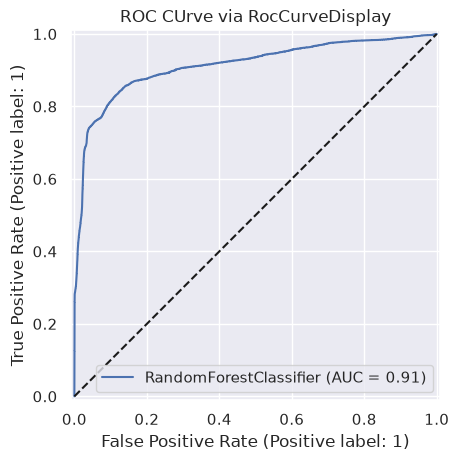

In [159]:
RocCurveDisplay.from_estimator(rf_model, X_test_final, y_test)

plt.title('ROC CUrve via RocCurveDisplay')
plt.plot([0, 1], [0,1], 'k--')
plt.show()

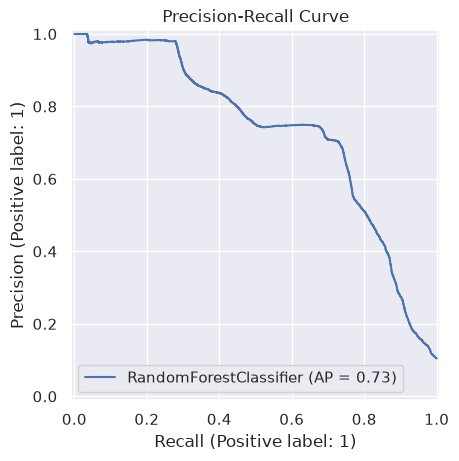

In [161]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_estimator(rf_model, X_test_final, y_test)

plt.title('Precision-Recall Curve')
plt.show()

['model/0626_rf_v1_pipeline.joblib']

import joblib
joblib.dump(rf_model, 'model/rf_0626_v1.joblib')
print('Done!')

In [ ]:
import shap
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_final)

shap.summary_plot(shap_values[1], X_test_final, feature_names = X_train_final.columns)

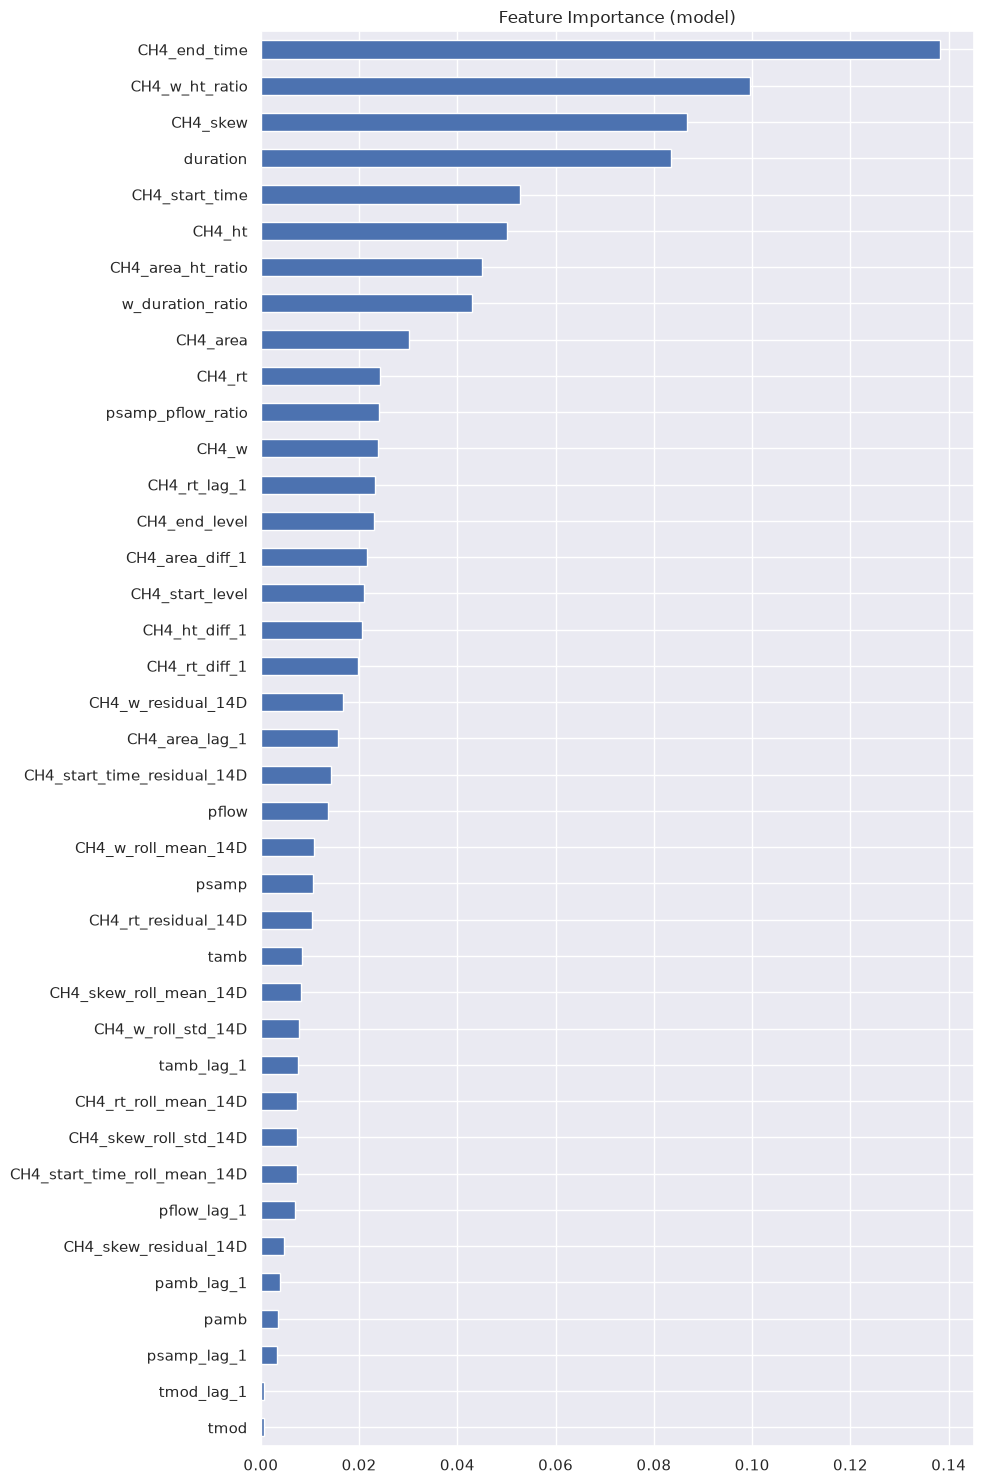

In [169]:
importances = pd.Series(rf_model.feature_importances_, index=X_train_final.columns)
importances = importances.sort_values()

fig, ax = plt.subplots(figsize=(10, 15))
importances.plot(kind='barh', ax=ax)

title = f'Feature Importance (model)'
ax.set_title(title)
fig.tight_layout()

plt.show()
plt.close(fig)

In [ ]:
from sklearn.pipeline import Pipeline
pipeline = Pipeline([
    ('scaler', scaler),
    ('rf', rf_model)
])

pipeline.fit(X_train_final, y_train)

joblib.dump(pipeline, 'model/0626_rf_v1_pipeline.joblib')

In [ ]:
import joblib
rf_model = joblib.load('model/rf_0626_v1.joblib')

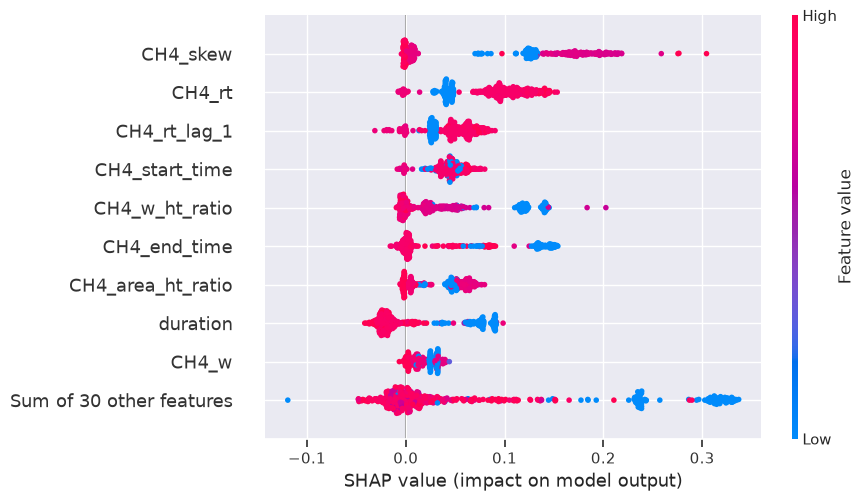

In [45]:
import shap

y_probs = rf_model.predict_proba(X_test_final)[:, 1]

threshold =  0.1323273563205446

X_anomalies = X_test_final[y_probs >= threshold]

X_sample = shap.utils.sample(X_anomalies, min(len(X_anomalies), 500), random_state=42)

explainer = shap.TreeExplainer(rf_model)

shap_values = explainer(X_sample)
shap.plots.beeswarm(shap_values[:, :, 1])

The performance is much better than the previous 